In [53]:
import gzip
import shutil
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import json
from scipy.stats import ttest_ind

In [54]:
subID='001'
sesID='001'
modality = "concentric"
torque_file_path = f"""\\Program Files\\DigiMove\\DigiMove\\DataAnalysisProject\\data\\MOXY-bids\\sub-{subID}\\ses-{sesID}\\beh\\sub-{subID}_ses-{sesID}_task-{modality}_recording-force_physio.tsv.gz"""


In [55]:
#Extract .gz file
with gzip.open(torque_file_path, 'rb') as f_in:
    with open('file', 'wb') as f_out:
       shutil.copyfileobj(f_in, f_out)

In [56]:
#load the tsv file that was extracted
df = pd.read_csv(torque_file_path, sep='\t', header=None, names=['torque_Nm'])
#display the first few rows of the dataframe to check if it loaded correctly
print(df.head())
print(df.columns)



   torque_Nm
0  -0.049765
1   0.430278
2   0.526286
3   0.814312
4   0.526286
Index(['torque_Nm'], dtype='str')


In [57]:
#load the JSON file to extract the sampling frequency
frequency_file_path = f"""\\Program Files\\DigiMove\\DigiMove\\DataAnalysisProject\\data\\MOXY-bids\\sub-{subID}\\ses-{sesID}\\beh\\sub-{subID}_ses-{sesID}_task-{modality}_recording-force_physio.json"""
with open(frequency_file_path, 'r') as f:
    frequency_data = json.load(f)
sampling_frequency = frequency_data['SamplingFrequency']


In [58]:
events_filepath = f"""\\Program Files\\DigiMove\\DigiMove\\DataAnalysisProject\\data\\MOXY-bids\\sub-{subID}\\ses-{sesID}\\beh\\sub-{subID}_ses-{sesID}_task-{modality}_events.tsv"""
events = pd.read_csv(events_filepath, sep="\t")
print(events)

#duration=events["onset"].max()
fs=sampling_frequency
df["time"] = np.arange(len(df))/fs


         onset  duration trial_type
0   918.723293         0        MVC
1   992.726686         0        MVC
2  1066.132068         0        MVC
3  1260.835733         0      Con50
4  1389.520155         0      Con50
5  1519.444601         0      Con50
6  1732.394609         0      Con30
7  1862.235053         0      Con30
8  1991.915494         0      Con30
9  2206.353531         0        MVC


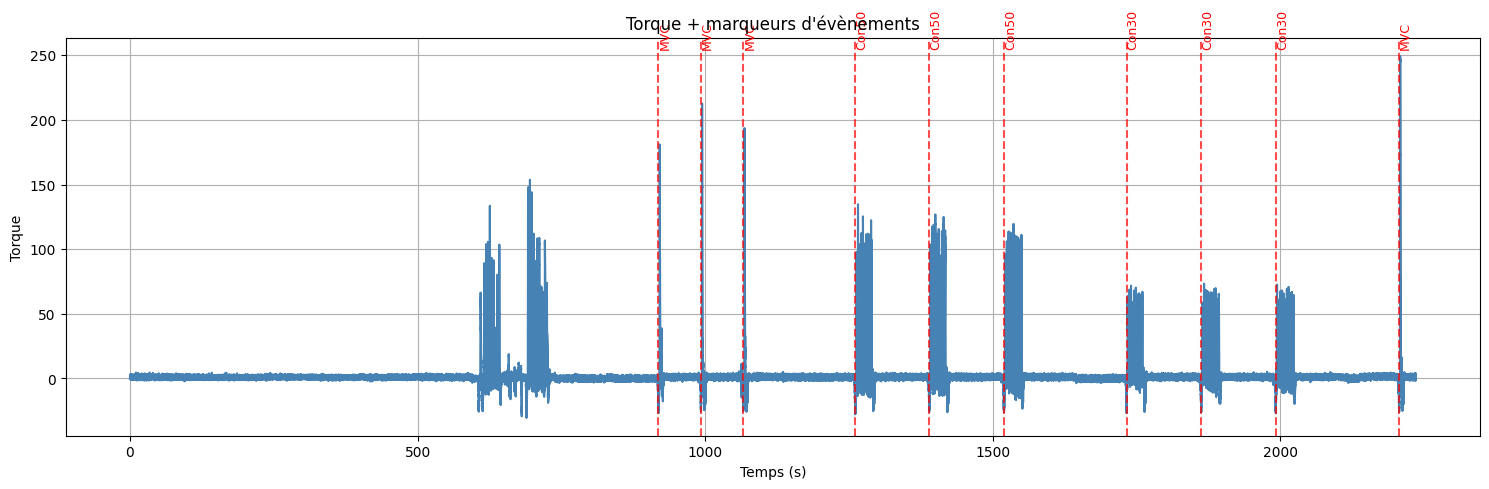

In [59]:
#visualize the data
plt.figure(figsize=(15, 5))

# Tracé du torque
plt.plot(df["time"], df["torque_Nm"], label="Torque", color="steelblue")

# Lignes verticales automatiques
for onset, label in zip(events["onset"], events["trial_type"]):
    plt.axvline(onset, color="red", linestyle="--", alpha=0.7)
    plt.text(onset, df["torque_Nm"].max()*1.02, label, rotation=90,
             verticalalignment="bottom", fontsize=9, color="red")

plt.xlabel("Temps (s)")
plt.ylabel("Torque")
plt.title("Torque + marqueurs d'évènements")
plt.grid(True)
plt.tight_layout()
plt.show()


Mean Torque: 3.460985687269715 Nm
Standard Deviation of Torque: 16.318759060519778 Nm
Skewness of Torque: 5.532165591180922
Kurtosis of Torque: 38.3847428505714


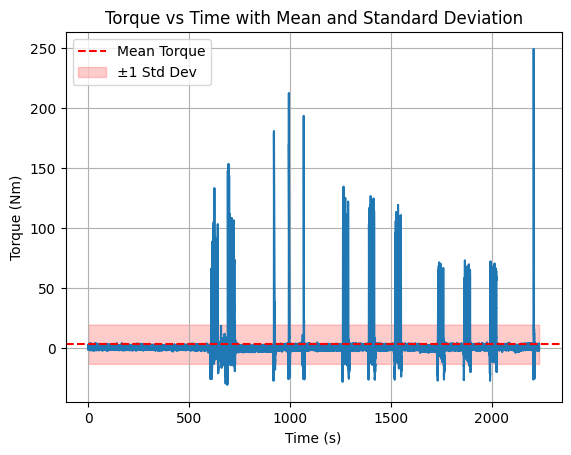

In [60]:
#extract the mean  
mean_torque = df['torque_Nm'].mean()
print(f'Mean Torque: {mean_torque} Nm')

#extract the strandard deviation
std_torque = df['torque_Nm'].std()
print(f'Standard Deviation of Torque: {std_torque} Nm')

#extract skewness
skewness_torque = df['torque_Nm'].skew()
print(f'Skewness of Torque: {skewness_torque}')

#extract kurtosis
kurtosis_torque = df['torque_Nm'].kurtosis()
print(f'Kurtosis of Torque: {kurtosis_torque}')

#and plot the linegraph 

plt.plot(df['time'], df['torque_Nm'])
plt.axhline(mean_torque, color='red', linestyle='--', label='Mean Torque')
plt.fill_between(df['time'], mean_torque - std_torque, mean_torque + std_torque, color='red', alpha=0.2, label='±1 Std Dev')
plt.xlabel('Time (s)')  
plt.ylabel('Torque (Nm)')
plt.title('Torque vs Time with Mean and Standard Deviation')
plt.legend()
plt.grid()
plt.show()



In [61]:
#Compute the mean of the torque values for the 3 MVC
mvc_events = events[events['trial_type'] == 'MVC']

mvc_max_values = []

window = 6  # fenêtre ±6 seconde autour du MVC (modifiable)

for _, row in mvc_events.iterrows():
    t0 = row['onset']
    start = t0
    end = t0 + window

    segment = df[(df['time'] >= start) & (df['time'] <= end)]
    
    mvc_max = segment['torque_Nm'].max()
    mvc_max_values.append(float(mvc_max))

print("Max torque for each MVC:", mvc_max_values)

#Calculate the average of the max torque values across the 3 first MVCs
average_mvc_max = np.mean(mvc_max_values[0:3])
print(f'Average Max Torque across the 3 first MVCs: {average_mvc_max} Nm')

#Unpaired t-test between the average_mvc_max  and the last MVC to see if there is a significant difference
import numpy as np
from scipy.stats import ttest_1samp

mvc_max_values = [1.9298302, 1.924031, 1.9249976, 1.9259641]

group_A = np.array(mvc_max_values[0:3])   # 3 premiers MVC
last = mvc_max_values[-1]                 # 4e MVC

t_stat, p_value = ttest_1samp(group_A, last)

print("T‑statistic:", t_stat)
print("P‑value:", p_value)

Max torque for each MVC: [181.0705, 212.70534, 193.69563, 249.42863]
Average Max Torque across the 3 first MVCs: 195.8238233333333 Nm
T‑statistic: 0.17959990709405163
P‑value: 0.8740155666594063
